# PCA Tối ưu hoá Đa Mục tiêu với Ràng buộc Phần cứng Lượng tử (v4)
## Contribution 1: Hardware-aware Quantum Embedding Optimization

**Hàm mục tiêu (trên tập candidates đã lọc):**

$$F(n) = \alpha \cdot V(n) + \beta \cdot S_{\text{norm}}(n) - \gamma \cdot Q(n)$$

**Cải tiến :**

| Bước | Mô tả | Cải tiến |
|------|-------|----------|
| **Input** | Đọc từ `NSL_KDD_Train_Selected.csv` (K features sau SelectKBest) | Khớp pipeline |
| **Scaling** | `MinMaxScaler([0, π])` thay vì `StandardScaler` | Dùng cho QSVM |
| **Zero-leakage** | `pca.fit_transform(X_train)` / `pca.transform(X_test)` | Nhất quán `.py` |
| **Artifact** | Lưu `pca.joblib` + `scaler_minmax_pi.joblib` vào `models/` | Reproducible |
| **Sanity checks** | Kiểm tra shape, range [0, π], NaN sau pipeline | Theo `.py` |

**Zero-leakage contract (theo data_preprocessing.py):**
```
pca.fit_transform(X_train)         ← eigenvectors từ train ONLY
pca.transform(X_test)              ← NEVER fit on test
scaler.fit_transform(X_train_pca)  ← min/max từ train ONLY
scaler.transform(X_test_pca)       ← NEVER fit on test
```

## 0. Cấu hình & Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
warnings.filterwarnings('ignore')

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# -- Cau hinh chinh --
DATA_TYPE          = 'NSL-KDD'
VARIANCE_THRESHOLD = 0.85
N_RANGE            = range(2, 11)
GRID_RESOLUTION    = 30
N_BOOTSTRAP        = 200
BOOTSTRAP_SAMPLE   = 5000
ANGLE_MAX          = np.pi   # RY/RX gate rotation range [0, pi]

# -- Duong dan -- dung output tu selectkbest_nslkdd.ipynb --
LABEL_COLS = ['label', 'label_binary', 'label_multiclass', 'attack_category']
DATA_PATHS = {
    'NSL-KDD'  : '../data/processed_data/NSL_KDD_Train_Cleaned.csv',
    'UNSW-NB15': '../data/processed_data/UNSW_NB15_Train_Selected.csv',
}
TEST_PATHS = {
    'NSL-KDD'  : '../data/processed_data/NSL_KDD_Test_Cleaned.csv',
    'UNSW-NB15': '../data/processed_data/UNSW_NB15_Test_Selected.csv',
}

FEATURE_SELECTOR_PATHS = {
    'NSL-KDD'  : '../models/feature_selector_k20.joblib',
    'UNSW-NB15': '../models/feature_selector_k20.joblib',
}

OUTPUT_DIR = '../data/processed_data'
MODELS_DIR = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Config OK')
print(f'  Dataset            : {DATA_TYPE}')
print(f'  Variance threshold : {VARIANCE_THRESHOLD:.0%}  (hard constraint)')
print(f'  ANGLE_MAX          : {ANGLE_MAX:.6f} rad  (= pi, RY gate range)')
print(f'  n range            : {list(N_RANGE)}')
print(f'  Grid resolution    : {GRID_RESOLUTION} -> ~{GRID_RESOLUTION*(GRID_RESOLUTION-1)//2} simplex points')
print(f'  Bootstrap iters    : {N_BOOTSTRAP} x {BOOTSTRAP_SAMPLE} samples')

Config OK
  Dataset            : NSL-KDD
  Variance threshold : 85%  (hard constraint)
  ANGLE_MAX          : 3.141593 rad  (= pi, RY gate range)
  n range            : [2, 3, 4, 5, 6, 7, 8, 9, 10]
  Grid resolution    : 30 -> ~435 simplex points
  Bootstrap iters    : 200 x 5000 samples


## 1. Các hàm tiện ích

In [13]:
def calculate_fisher_score(X_pca, y):
    """
    Fisher Score tung PC rieng le -- ho tro binary va multi-class.
    Returns: scores (n_components,), mean_score float
    """
    labels = np.unique(y)
    if len(labels) < 2:
        raise ValueError(f'Can it nhat 2 lop, nhan {len(labels)}.')
    mu_all = np.mean(X_pca, axis=0)
    S_B = np.zeros(X_pca.shape[1])
    S_W = np.zeros(X_pca.shape[1])
    for lbl in labels:
        Xk = X_pca[y == lbl]
        nk = len(Xk)
        mu_k = np.mean(Xk, axis=0)
        S_B += nk * (mu_k - mu_all) ** 2
        S_W += nk * np.var(Xk, axis=0)
    scores = S_B / (S_W + 1e-8)
    return scores, float(np.mean(scores))


def quantum_hardware_cost(n, reps=2, normalize_max=10):
    """
    Chi phi ZZFeatureMap thuc te:
      - 1-qubit gates : n * reps           [O(n)]
      - 2-qubit gates : n*(n-1)/2 * reps   [O(n^2)] -- penalty x5
    Normalize theo n_max=10.

    Ly do penalty x5:
      2-qubit gate error rate ~5-10x cao hon 1-qubit tren NISQ hardware
      (IBM Quantum / Google Sycamore calibration data).
    """
    n1q = n * reps
    n2q = (n * (n - 1) // 2) * reps
    raw = n1q + 5 * n2q

    n1q_max = normalize_max * reps
    n2q_max = (normalize_max * (normalize_max - 1) // 2) * reps
    raw_max = n1q_max + 5 * n2q_max
    return raw / raw_max


def simplex_grid(resolution):
    """Sinh cac diem (a, b, g) deu tren simplex a+b+g=1."""
    points = []
    for i in range(resolution + 1):
        for j in range(resolution + 1 - i):
            k = resolution - i - j
            points.append((i / resolution, j / resolution, k / resolution))
    return np.array(points)


print('Utility functions OK')
print()
print(f'{"n":>4} | {"1Q":>4} | {"2Q":>6} | {"Q(n)":>8} | {"DeltaQ":>10}')
prev = 0
for n in range(2, 11):
    q = quantum_hardware_cost(n)
    print(f'{n:>4} | {n*2:>4} | {n*(n-1)//2*2:>6} | {q:>8.4f} | +{(q-prev)*100:>7.2f}%')
    prev = q
pts = simplex_grid(GRID_RESOLUTION)
print(f'\nSimplex grid: {len(pts)} diem voi resolution={GRID_RESOLUTION}')

Utility functions OK

   n |   1Q |     2Q |     Q(n) |     DeltaQ
   2 |    4 |      2 |   0.0298 | +   2.98%
   3 |    6 |      6 |   0.0766 | +   4.68%
   4 |    8 |     12 |   0.1447 | +   6.81%
   5 |   10 |     20 |   0.2340 | +   8.94%
   6 |   12 |     30 |   0.3447 | +  11.06%
   7 |   14 |     42 |   0.4766 | +  13.19%
   8 |   16 |     56 |   0.6298 | +  15.32%
   9 |   18 |     72 |   0.8043 | +  17.45%
  10 |   20 |     90 |   1.0000 | +  19.57%

Simplex grid: 496 diem voi resolution=30


## 2. Tải dữ liệu

**Input:** `NSL_KDD_Train_Cleaned.csv` và `NSL_KDD_Test_Cleaned.csv` và `feature_selector_k20.joblib` từ `selectkbest_nslkdd.ipynb`

**Scaling:** `MinMaxScaler([0, π])` thay vì `StandardScaler` vì:
- Output cuối cùng phải là rotation angle cho RY gate: `|ψ⟩ = RY(x_i)|0⟩`
- `[0, π]` khai thác toàn bộ Bloch hemisphere, không bị wrap-around
- `data_preprocessing.py` dùng chính xác scale này

In [14]:
train_df = pd.read_csv(DATA_PATHS[DATA_TYPE])
test_df  = pd.read_csv(TEST_PATHS[DATA_TYPE])

feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

# Load selector joblib va transform (KHONG fit lai)
selector     = joblib.load(FEATURE_SELECTOR_PATHS[DATA_TYPE])
X_train_raw  = selector.transform(train_df[feature_cols].to_numpy(dtype=np.float32))
X_test_raw   = selector.transform(test_df[feature_cols].to_numpy(dtype=np.float32))

# Lay ten features duoc chon
selected_mask  = selector.get_support()
selected_feats = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

y_train = train_df['label_binary'].to_numpy(dtype=np.int64)
y_test  = test_df['label_binary'].to_numpy(dtype=np.int64)

# Alias dung cho cac cell phan tich phia sau
y = y_train
X = X_train_raw

print(f'Dataset  : {DATA_TYPE}')
print(f'Cleaned  : {DATA_PATHS[DATA_TYPE]}')
print(f'Selector : {FEATURE_SELECTOR_PATHS[DATA_TYPE]}')
print(f'Train    : {X_train_raw.shape}  ({X_train_raw.shape[1]} features sau SelectKBest)')
print(f'Test     : {X_test_raw.shape}')
print(f'Feature range train: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}] (ky vong [0,1])')
print(f'NaN train: {np.isnan(X_train_raw).sum()} | NaN test: {np.isnan(X_test_raw).sum()}')
print()
unique, counts = np.unique(y_train, return_counts=True)
print('Phan bo label_binary (train):')
for u, c in zip(unique, counts):
    print(f'  {u} : {c:,}  ({c/len(y_train):.1%})')

print()
print(f'=== Head data sau SelectKBest transform (5 dong dau) ===')
head_df = pd.DataFrame(X_train_raw[:5], columns=selected_feats)
print(head_df.to_string())
print(f'Dtype: {X_train_raw.dtype} | Shape: {X_train_raw.shape}')

Dataset  : NSL-KDD
Cleaned  : ../data/processed_data/NSL_KDD_Train_Cleaned.csv
Selector : ../models/feature_selector_k20.joblib
Train    : (125973, 20)  (20 features sau SelectKBest)
Test     : (22544, 20)
Feature range train: [0.0000, 1.0000] (ky vong [0,1])
NaN train: 0 | NaN test: 0

Phan bo label_binary (train):
  0 : 67,343  (53.5%)
  1 : 58,630  (46.5%)

=== Head data sau SelectKBest transform (5 dong dau) ===
   logged_in     count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  dst_host_srv_rerror_rate  service_domain_u  service_http  service_private  flag_S0  flag_SF
0        0.0  0.003914          0.0              0.0          0.0              0.0           1.00        0.588235            0.098039                    0.17                    0.03                  0.00                      0.00      

## 3. Thu thập chỉ số thô cho toàn bộ N_RANGE

In [15]:
results_all = []

print(f'{"n":>4} | {"V(n)":>8} | {"S(n)":>8} | {"Q(n)":>8} | {"DBI":>8} | Pass V>=' + str(VARIANCE_THRESHOLD))
print('-' * 68)

for n in N_RANGE:
    # PCA fit tren X_train (train only -- zero-leakage)
    pca_tmp  = PCA(n_components=n, random_state=GLOBAL_SEED)
    X_pca    = pca_tmp.fit_transform(X)   # X = X_train_raw
    V_n      = float(np.sum(pca_tmp.explained_variance_ratio_))

    per_pc_scores, S_n = calculate_fisher_score(X_pca, y)
    Q_n  = quantum_hardware_cost(n)
    dbi  = davies_bouldin_score(X_pca, y)
    passes = V_n >= VARIANCE_THRESHOLD

    results_all.append({
        'n'            : n,
        'V_n'          : V_n,
        'S_n'          : S_n,
        'per_pc_scores': per_pc_scores,
        'Q_n'          : Q_n,
        'DBI'          : dbi,
        'passes_hard'  : passes,
        'X_pca'        : X_pca,
        'pca_obj'      : pca_tmp,   # cache pca object cho buoc cuoi
    })
    flag = 'OK' if passes else 'LOAI'
    print(f'{n:>4} | {V_n:>8.4f} | {S_n:>8.4f} | {Q_n:>8.4f} | {dbi:>8.4f} | {flag}')

results_candidates = [r for r in results_all if r['passes_hard']]
n_candidates = [r['n'] for r in results_candidates]

print()
print(f'Hard constraint V(n) >= {VARIANCE_THRESHOLD:.0%}')
print(f'  Bi loai           : n in {[r["n"] for r in results_all if not r["passes_hard"]]}')
print(f'  Candidates hop le : n in {n_candidates}')

# -- Normalize Fisher Score (global) --
s_all   = [r['S_n'] for r in results_all]
s_min_g = min(s_all); s_max_g = max(s_all)
s_denom = (s_max_g - s_min_g) if s_max_g > s_min_g else 1.0
for r in results_all:
    r['S_norm'] = (r['S_n'] - s_min_g) / s_denom

# -- Normalize DBI (lower = better) --
dbi_all = [r['DBI'] for r in results_all]
dbi_min_g = min(dbi_all); dbi_max_g = max(dbi_all)
dbi_denom = (dbi_max_g - dbi_min_g) if dbi_max_g > dbi_min_g else 1.0
for r in results_all:
    r['DBI_norm'] = 1.0 - (r['DBI'] - dbi_min_g) / dbi_denom

print(f'  S_norm range (toan bo)  : [{min(r["S_norm"] for r in results_all):.3f}, {max(r["S_norm"] for r in results_all):.3f}]')
print(f'  S_norm range (candidates): [{min(r["S_norm"] for r in results_candidates):.3f}, {max(r["S_norm"] for r in results_candidates):.3f}]')

   n |     V(n) |     S(n) |     Q(n) |      DBI | Pass V>=0.85
--------------------------------------------------------------------
   2 |   0.7418 |   0.9413 |   0.0298 |   0.8746 | LOAI
   3 |   0.8210 |   0.6275 |   0.0766 |   1.0179 | LOAI
   4 |   0.8662 |   0.4711 |   0.1447 |   1.0846 | OK
   5 |   0.9040 |   0.3777 |   0.2340 |   1.1311 | OK
   6 |   0.9391 |   0.3154 |   0.3447 |   1.1718 | OK
   7 |   0.9524 |   0.2717 |   0.4766 |   1.1850 | OK
   8 |   0.9643 |   0.2399 |   0.6298 |   1.1985 | OK
   9 |   0.9729 |   0.2144 |   0.8043 |   1.2065 | OK
  10 |   0.9810 |   0.1957 |   1.0000 |   1.2140 | OK

Hard constraint V(n) >= 85%
  Bi loai           : n in [2, 3]
  Candidates hop le : n in [4, 5, 6, 7, 8, 9, 10]
  S_norm range (toan bo)  : [0.000, 1.000]
  S_norm range (candidates): [0.000, 0.369]


## 4. Trực quan hoá ràng buộc cứng

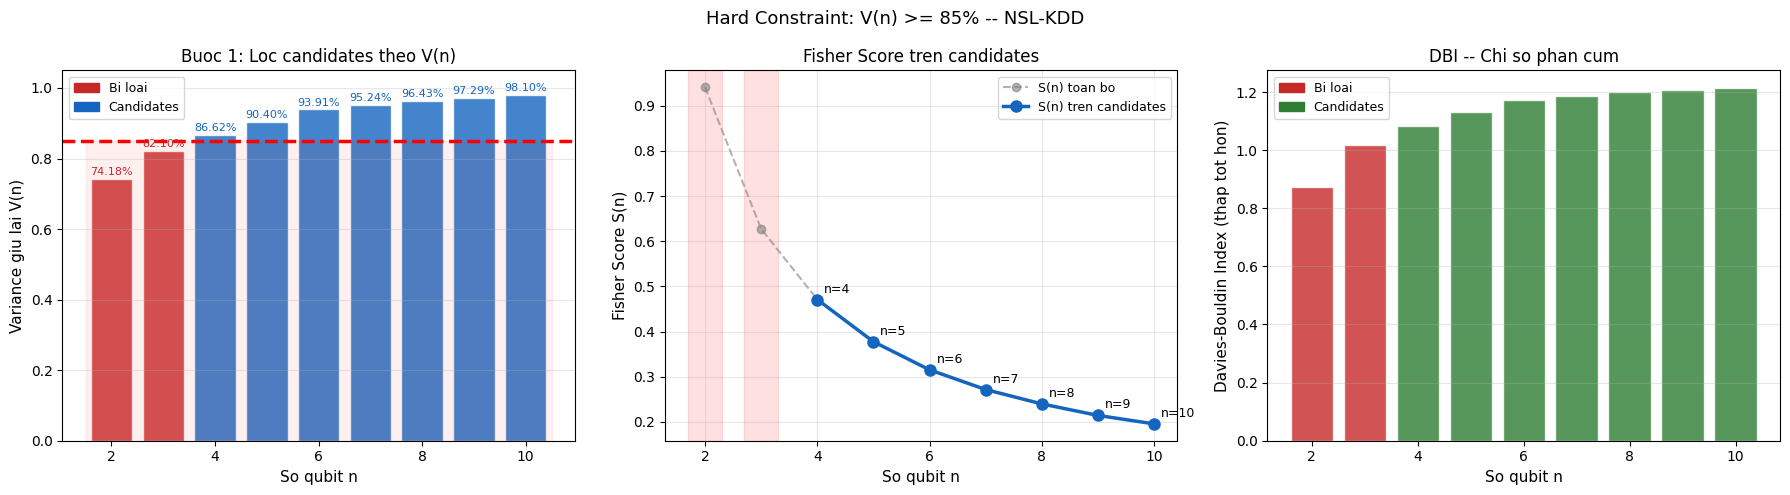

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Hard Constraint: V(n) >= {VARIANCE_THRESHOLD:.0%} -- {DATA_TYPE}', fontsize=13)

n_vals_all = [r['n']   for r in results_all]
v_vals_all = [r['V_n'] for r in results_all]
s_vals_all = [r['S_n'] for r in results_all]
d_vals_all = [r['DBI'] for r in results_all]

# Plot 1: Variance
ax = axes[0]
colors_bar = ['#C62828' if not r['passes_hard'] else '#1565C0' for r in results_all]
bars = ax.bar(n_vals_all, v_vals_all, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(VARIANCE_THRESHOLD, color='red', linewidth=2.5, linestyle='--')
ax.fill_between([1.5, max(N_RANGE)+0.5], 0, VARIANCE_THRESHOLD, alpha=0.06, color='red')
for bar, r in zip(bars, results_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{r['V_n']:.2%}", ha='center', va='bottom', fontsize=8,
            color='#C62828' if not r['passes_hard'] else '#1565C0')
ax.set_xlabel('So qubit n', fontsize=11)
ax.set_ylabel('Variance giu lai V(n)', fontsize=11)
ax.set_title('Buoc 1: Loc candidates theo V(n)')
ax.set_ylim(0, 1.05)
ax.legend(handles=[mpatches.Patch(color='#C62828', label='Bi loai'),
                   mpatches.Patch(color='#1565C0', label='Candidates')], fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Fisher Score
ax2 = axes[1]
ax2.plot(n_vals_all, s_vals_all, 'o--', color='gray', linewidth=1.5, label='S(n) toan bo', alpha=0.6)
ax2.plot(n_candidates, [r['S_n'] for r in results_candidates],
         'o-', color='#1565C0', linewidth=2.5, markersize=8, label='S(n) tren candidates')
for r in results_candidates:
    ax2.annotate(f"n={r['n']}", (r['n'], r['S_n']), textcoords='offset points', xytext=(5,5), fontsize=9)
for r in results_all:
    if not r['passes_hard']:
        ax2.axvspan(r['n']-0.3, r['n']+0.3, alpha=0.12, color='red')
ax2.set_xlabel('So qubit n', fontsize=11)
ax2.set_ylabel('Fisher Score S(n)', fontsize=11)
ax2.set_title('Fisher Score tren candidates')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: DBI
ax3 = axes[2]
colors_dbi = ['#C62828' if not r['passes_hard'] else '#2E7D32' for r in results_all]
ax3.bar(n_vals_all, d_vals_all, color=colors_dbi, alpha=0.8, edgecolor='white')
ax3.set_xlabel('So qubit n', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index (thap tot hon)', fontsize=11)
ax3.set_title('DBI -- Chi so phan cum')
ax3.legend(handles=[mpatches.Patch(color='#C62828', label='Bi loai'),
                    mpatches.Patch(color='#2E7D32', label='Candidates')], fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_hard_constraint.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tìm trọng số tối ưu — Simplex Grid Search

Grid search trên simplex α+β+γ=1 dùng Davies-Bouldin Index (O(k·n), nhanh hơn Silhouette ~100x).
Silhouette chỉ dùng để **validate** kết quả cuối cùng.

In [17]:
def find_optimal_weights_grid(candidates, grid_resolution=30):
    grid  = simplex_grid(grid_resolution)
    best_dbi, best_weights, weight_log = np.inf, None, []
    for alpha, beta, gamma in grid:
        if alpha < 0.05 or beta < 0.05 or gamma > 0.5:
            continue
        f_scores = [
            alpha * r['V_n'] + beta * r['S_norm'] - gamma * r['Q_n']
            for r in candidates
        ]
        best_idx = int(np.argmax(f_scores))
        best_n   = candidates[best_idx]['n']
        dbi      = candidates[best_idx]['DBI']
        weight_log.append({'alpha': alpha, 'beta': beta, 'gamma': gamma,
                           'best_n': best_n, 'dbi': dbi, 'f_score': f_scores[best_idx]})
        if dbi < best_dbi:
            best_dbi = dbi
            best_weights = {'alpha': alpha, 'beta': beta, 'gamma': gamma}
    return best_weights, weight_log, best_dbi


grid_pts = simplex_grid(GRID_RESOLUTION)
print(f'Grid search tren {len(results_candidates)} candidates: n in {n_candidates}')
print(f'Simplex points: {len(grid_pts)}  (resolution={GRID_RESOLUTION})')
print(f'Metric: Davies-Bouldin Index (O(k*n))')

best_weights, weight_log, best_dbi = find_optimal_weights_grid(
    results_candidates, grid_resolution=GRID_RESOLUTION
)

alpha = best_weights['alpha']
beta  = best_weights['beta']
gamma = best_weights['gamma']

print(f'\nGrid search hoan tat')
print(f'  Best DBI     : {best_dbi:.4f}')
print(f'  a (variance) = {alpha:.4f}')
print(f'  b (fisher)   = {beta:.4f}')
print(f'  g (hardware) = {gamma:.4f}')
print(f'  a+b+g        = {alpha+beta+gamma:.6f} ~= 1.0')

Grid search tren 7 candidates: n in [4, 5, 6, 7, 8, 9, 10]
Simplex points: 496  (resolution=30)
Metric: Davies-Bouldin Index (O(k*n))

Grid search hoan tat
  Best DBI     : 1.0846
  a (variance) = 0.0667
  b (fisher)   = 0.4333
  g (hardware) = 0.5000
  a+b+g        = 1.000000 ~= 1.0


## 6. Phân tích landscape trọng số

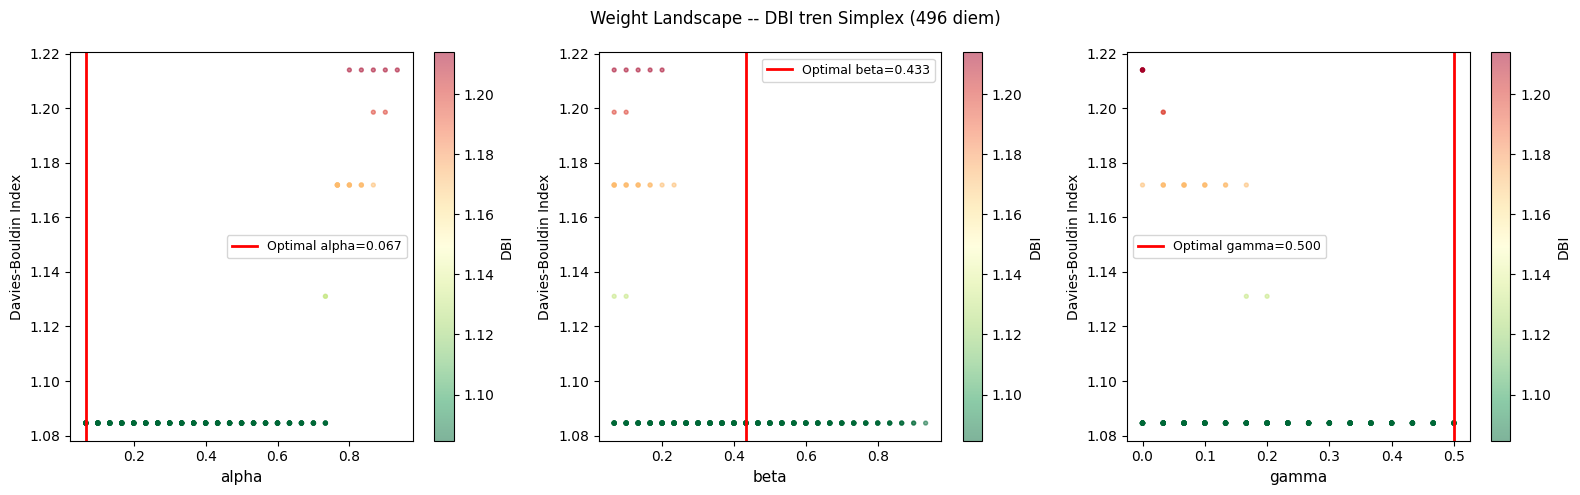

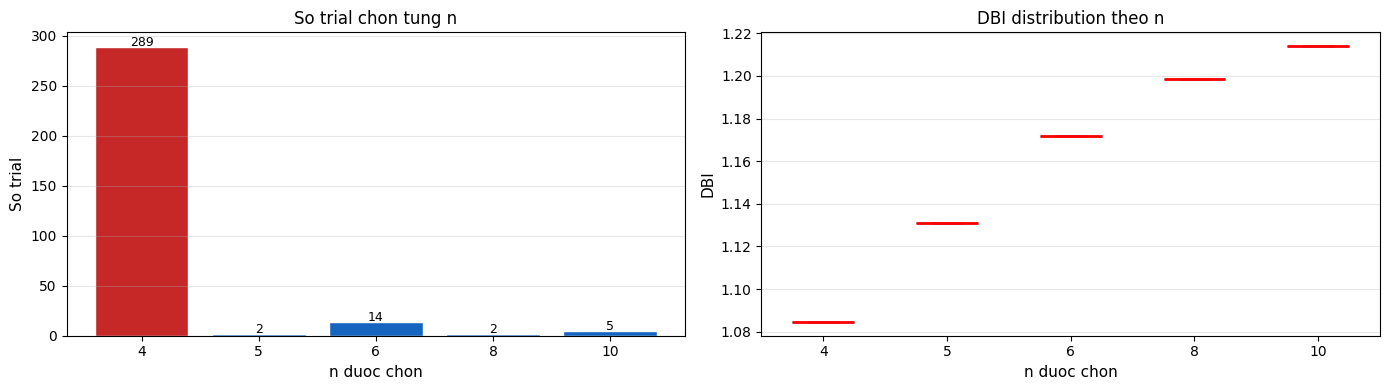

In [18]:
log_df = pd.DataFrame(weight_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Weight Landscape -- DBI tren Simplex ({len(grid_pts)} diem)', fontsize=12)

for ax, param in zip(axes, ['alpha', 'beta', 'gamma']):
    sc = ax.scatter(log_df[param], log_df['dbi'], c=log_df['dbi'],
                    cmap='RdYlGn_r', alpha=0.5, s=8)
    ax.axvline(best_weights[param], color='red', linewidth=2,
               label=f'Optimal {param}={best_weights[param]:.3f}')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Davies-Bouldin Index', fontsize=10)
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='DBI')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_weight_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution of best_n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
n_counts = log_df['best_n'].value_counts().sort_index()
colors_n = [('#C62828' if n == int(log_df.loc[log_df['dbi'].idxmin(), 'best_n']) else '#1565C0')
            for n in n_counts.index]
ax1.bar(n_counts.index.astype(str), n_counts.values, color=colors_n, edgecolor='white')
ax1.set_xlabel('n duoc chon', fontsize=11)
ax1.set_ylabel('So trial', fontsize=11)
ax1.set_title('So trial chon tung n')
ax1.grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(n_counts.items()):
    ax1.text(i, val + 1, str(val), ha='center', fontsize=9)

dbi_by_n = [log_df[log_df['best_n'] == n]['dbi'].values for n in sorted(log_df['best_n'].unique())]
ax2.boxplot(dbi_by_n, labels=[str(n) for n in sorted(log_df['best_n'].unique())],
            patch_artist=True, boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_xlabel('n duoc chon', fontsize=11)
ax2.set_ylabel('DBI', fontsize=11)
ax2.set_title('DBI distribution theo n')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Tính F(n) và chọn n tối ưu

In [19]:
for r in results_candidates:
    r['F_n'] = alpha * r['V_n'] + beta * r['S_norm'] - gamma * r['Q_n']

best_candidate = max(results_candidates, key=lambda r: r['F_n'])
n_chosen       = best_candidate['n']

rows = []
for r in results_all:
    rows.append({
        'n'     : r['n'],
        'V(n)'  : r['V_n'],
        'S(n)'  : r['S_n'],
        'S_norm': r['S_norm'],
        'DBI'   : r['DBI'],
        'Q(n)'  : r['Q_n'],
        'Status': 'candidate' if r['passes_hard'] else f'loai (V<{VARIANCE_THRESHOLD:.0%})',
        'F(n)'  : r.get('F_n', float('nan')),
    })
df_table = pd.DataFrame(rows)

def style_rows(row):
    if 'loai' in str(row['Status']):
        return ['background-color: #fce4e4; color: #999'] * len(row)
    if row['n'] == n_chosen:
        return ['background-color: #d1e7dd; font-weight: bold'] * len(row)
    return [''] * len(row)

print(f'BANG TOI UU HOA DA MUC TIEU ({DATA_TYPE})')
print(f'  Hard constraint: V(n) >= {VARIANCE_THRESHOLD:.0%}')
print(f'  a={alpha:.4f} | b={beta:.4f} | g={gamma:.4f}  (grid search, DBI metric)')
display(df_table.style
    .apply(style_rows, axis=1)
    .format({
        'V(n)'  : '{:.2%}',
        'S(n)'  : '{:.4f}',
        'S_norm': '{:.4f}',
        'DBI'   : '{:.4f}',
        'Q(n)'  : '{:.4f}',
        'F(n)'  : lambda x: f'{x:.4f}' if not np.isnan(x) else '--',
    })
)

print(f'\nn toi uu duoc chon : {n_chosen} qubits')
print(f'  F(n) cao nhat    : {best_candidate["F_n"]:.4f}')
print(f'  Variance giu lai : {best_candidate["V_n"]:.2%}')
print(f'  Fisher Score     : {best_candidate["S_n"]:.4f}')
print(f'  DBI              : {best_candidate["DBI"]:.4f}')
print(f'  Hardware cost    : {best_candidate["Q_n"]:.4f}')

BANG TOI UU HOA DA MUC TIEU (NSL-KDD)
  Hard constraint: V(n) >= 85%
  a=0.0667 | b=0.4333 | g=0.5000  (grid search, DBI metric)


,n,V(n),S(n),S_norm,DBI,Q(n),Status,F(n)
0,2,74.18%,0.9413,1.0000,0.8746,0.0298,loai (V<85%),--
1,3,82.10%,0.6275,0.5792,1.0179,0.0766,loai (V<85%),--
2,4,86.62%,0.4711,0.3694,1.0846,0.1447,candidate,0.1455
3,5,90.40%,0.3777,0.2442,1.1311,0.2340,candidate,0.0490
4,6,93.91%,0.3154,0.1605,1.1718,0.3447,candidate,-0.0402
5,7,95.24%,0.2717,0.1020,1.1850,0.4766,candidate,-0.1306
6,8,96.43%,0.2399,0.0593,1.1985,0.6298,candidate,-0.2249
7,9,97.29%,0.2144,0.0251,1.2065,0.8043,candidate,-0.3264
8,10,98.10%,0.1957,0.0000,1.2140,1.0000,candidate,-0.4346



n toi uu duoc chon : 4 qubits
  F(n) cao nhat    : 0.1455
  Variance giu lai : 86.62%
  Fisher Score     : 0.4711
  DBI              : 1.0846
  Hardware cost    : 0.1447


## 8. Validation: Silhouette Score cho n tối ưu (chạy 1 lần)

In [20]:
print(f'Tinh Silhouette Score de validate n={n_chosen}...')
X_pca_chosen = best_candidate['X_pca']

sil_chosen = silhouette_score(
    X_pca_chosen, y, sample_size=min(10000, len(y)), random_state=GLOBAL_SEED
)

print(f'\n{"n":>4} | {"DBI":>8} | {"Silhouette":>12} | Chon')
print('-' * 42)
for r in results_candidates:
    sil_r = silhouette_score(r['X_pca'], y, sample_size=min(5000, len(y)), random_state=GLOBAL_SEED)
    r['silhouette'] = sil_r
    mark = ' <- CHOSEN' if r['n'] == n_chosen else ''
    print(f"{r['n']:>4} | {r['DBI']:>8.4f} | {sil_r:>12.4f} |{mark}")

print(f'\nSilhouette Score (n={n_chosen}) = {sil_chosen:.4f}')
print('  (1.0 = hoan hao, 0.0 = overlapping, -1.0 = sai cluster)')

dbi_vals = np.array([r['DBI'] for r in results_candidates])
sil_vals = np.array([r['silhouette'] for r in results_candidates])
corr = np.corrcoef(dbi_vals, sil_vals)[0, 1]
print(f'\nPearson corr(DBI, Silhouette) = {corr:.4f}')
print(f'  {"Cao -> DBI la proxy tot cho Silhouette" if abs(corr) > 0.7 else "Thap -> xem xet them"}')

Tinh Silhouette Score de validate n=4...

   n |      DBI |   Silhouette | Chon
------------------------------------------
   4 |   1.0846 |       0.4262 | <- CHOSEN
   5 |   1.1311 |       0.4099 |
   6 |   1.1718 |       0.3920 |
   7 |   1.1850 |       0.3861 |
   8 |   1.1985 |       0.3824 |
   9 |   1.2065 |       0.3798 |
  10 |   1.2140 |       0.3779 |

Silhouette Score (n=4) = 0.4285
  (1.0 = hoan hao, 0.0 = overlapping, -1.0 = sai cluster)

Pearson corr(DBI, Silhouette) = -0.9981
  Cao -> DBI la proxy tot cho Silhouette


## 9. Bootstrap Confidence Intervals cho F(n) và Silhouette

In [ ]:
def bootstrap_metrics(results_cands, n_bootstrap=200, sample_size=5000, seed=42):
    rng = np.random.default_rng(seed)
    N   = len(y)
    bs_results = {r['n']: {'F_vals': [], 'sil_vals': []} for r in results_cands}
    for i in range(n_bootstrap):
        idx  = rng.choice(N, size=min(sample_size, N), replace=True)
        y_bs = y[idx]
        for r in results_cands:
            X_bs = r['X_pca'][idx]
            _, S_bs = calculate_fisher_score(X_bs, y_bs)
            S_norm_bs = (S_bs - s_min_g) / s_denom
            F_bs = alpha * r['V_n'] + beta * S_norm_bs - gamma * r['Q_n']
            bs_results[r['n']]['F_vals'].append(F_bs)
            try:
                sil_bs = silhouette_score(X_bs, y_bs,
                                         sample_size=min(1000, len(y_bs)),
                                         random_state=int(i))
                bs_results[r['n']]['sil_vals'].append(sil_bs)
            except Exception:
                pass
    ci_results = {}
    for n_val, data in bs_results.items():
        f_arr = np.array(data['F_vals'])
        s_arr = np.array(data['sil_vals'])
        ci_results[n_val] = {
            'F_mean': np.mean(f_arr), 'F_ci': (np.percentile(f_arr, 2.5), np.percentile(f_arr, 97.5)),
            'F_std' : np.std(f_arr),
            'sil_mean': np.mean(s_arr), 'sil_ci': (np.percentile(s_arr, 2.5), np.percentile(s_arr, 97.5)),
            'sil_std' : np.std(s_arr),
        }
    return ci_results


print(f'Bootstrap CI ({N_BOOTSTRAP} iterations x {BOOTSTRAP_SAMPLE} samples)...')
ci = bootstrap_metrics(results_candidates, N_BOOTSTRAP, BOOTSTRAP_SAMPLE, GLOBAL_SEED)

print(f'\n{"n":>4} | {"F(n) mean":>10} | {"95% CI F":>22} | {"Sil mean":>10} | {"95% CI Sil":>20}')
print('-' * 75)
for r in results_candidates:
    n_val = r['n']
    c = ci[n_val]
    mark = ' *' if n_val == n_chosen else ''
    print(f"{n_val:>4} | {c['F_mean']:>10.4f} | "
          f"[{c['F_ci'][0]:>7.4f}, {c['F_ci'][1]:>7.4f}] | "
          f"{c['sil_mean']:>10.4f} | "
          f"[{c['sil_ci'][0]:>7.4f}, {c['sil_ci'][1]:>7.4f}]{mark}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Bootstrap 95% CI (n={N_BOOTSTRAP} iters) -- {DATA_TYPE}', fontsize=13)

n_list  = [r['n'] for r in results_candidates]
f_means = np.array([ci[n]['F_mean'] for n in n_list])
f_lo    = np.array([ci[n]['F_ci'][0] for n in n_list])
f_hi    = np.array([ci[n]['F_ci'][1] for n in n_list])
ax1.errorbar(n_list, f_means,
             yerr=[np.maximum(f_means-f_lo, 0), np.maximum(f_hi-f_means, 0)],
             fmt='none', color='black', capsize=5, linewidth=1.5)
ax1.scatter(n_list, f_means, color='#1565C0', s=60, zorder=4)
ax1.axvline(x=n_chosen, color='red', linestyle='--', linewidth=2, label=f'n*={n_chosen}')
ax1.set_xlabel('n (candidates)', fontsize=11)
ax1.set_ylabel('F(n) +/- 95% CI', fontsize=11)
ax1.set_title('Bootstrap CI cho Ham muc tieu F(n)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

s_means = [ci[n]['sil_mean'] for n in n_list]
s_lo    = [ci[n]['sil_ci'][0] for n in n_list]
s_hi    = [ci[n]['sil_ci'][1] for n in n_list]
colors_ci = ['#C62828' if n == n_chosen else '#1565C0' for n in n_list]
ax2.bar(n_list, s_means, color=colors_ci, alpha=0.7, edgecolor='white')
ax2.errorbar(n_list, s_means,
             yerr=[np.array(s_means)-np.array(s_lo), np.array(s_hi)-np.array(s_means)],
             fmt='none', color='black', capsize=5, linewidth=1.5)
ax2.axvline(x=n_chosen, color='red', linestyle='--', linewidth=2, label=f'n*={n_chosen}')
ax2.set_xlabel('n (candidates)', fontsize=11)
ax2.set_ylabel('Silhouette +/- 95% CI', fontsize=11)
ax2.set_title('Bootstrap CI cho Silhouette Score')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

Bootstrap CI (200 iterations x 5000 samples)...


## 10. Pareto Frontier — trên candidates hợp lệ

Pareto-optimal (candidates n in [4, 5, 6, 7, 8, 9, 10]): n in [4, 5, 6, 7, 8, 9, 10]

   n |     V(n) |   S_norm |     Q(n) |     F(n) |      DBI |      Sil | Pareto
------------------------------------------------------------------------------
   4 |   0.8662 |   0.3694 |   0.1447 |   0.1455 |   1.0846 |   0.4262 | YES *
   5 |   0.9040 |   0.2442 |   0.2340 |   0.0490 |   1.1311 |   0.4099 | YES
   6 |   0.9391 |   0.1605 |   0.3447 |  -0.0402 |   1.1718 |   0.3920 | YES
   7 |   0.9524 |   0.1020 |   0.4766 |  -0.1306 |   1.1850 |   0.3861 | YES
   8 |   0.9643 |   0.0593 |   0.6298 |  -0.2249 |   1.1985 |   0.3824 | YES
   9 |   0.9729 |   0.0251 |   0.8043 |  -0.3264 |   1.2065 |   0.3798 | YES
  10 |   0.9810 |   0.0000 |   1.0000 |  -0.4346 |   1.2140 |   0.3779 | YES


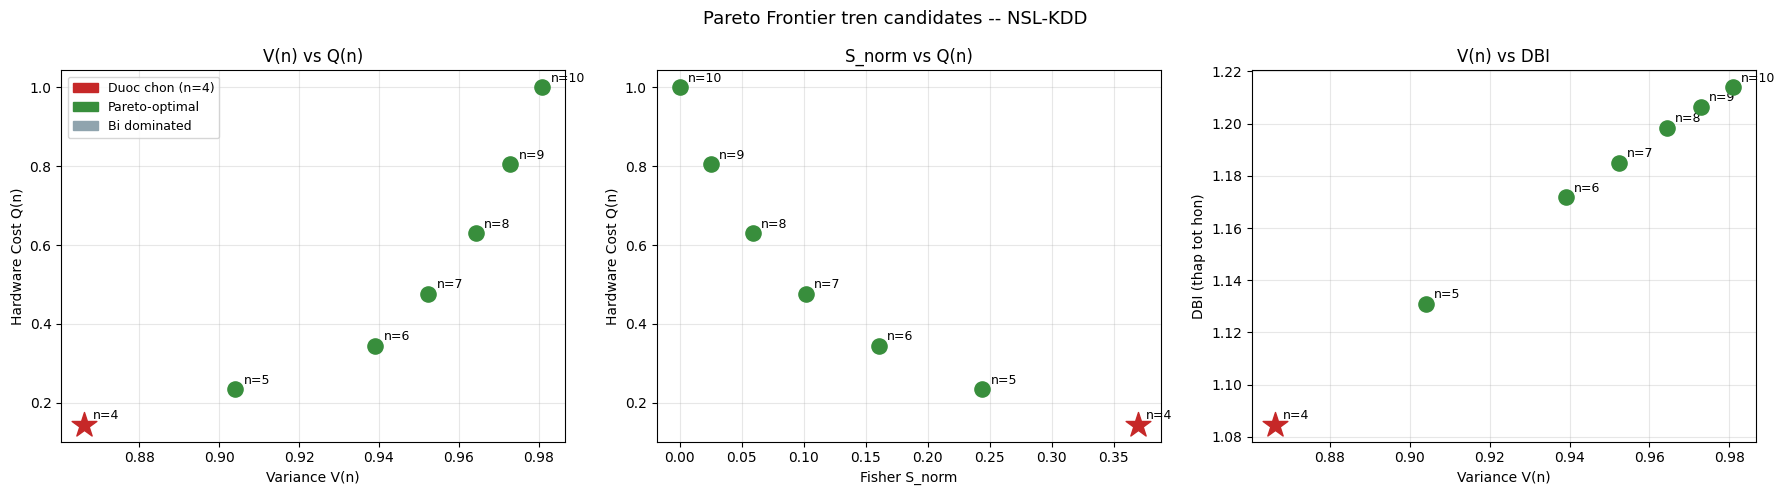

In [ ]:
def compute_pareto_frontier(candidates):
    pareto = []
    for i, ri in enumerate(candidates):
        dominated = False
        for j, rj in enumerate(candidates):
            if i == j:
                continue
            geq    = (rj['V_n'] >= ri['V_n'] and rj['S_norm'] >= ri['S_norm'] and rj['Q_n'] <= ri['Q_n'])
            strict = (rj['V_n'] > ri['V_n'] or rj['S_norm'] > ri['S_norm'] or rj['Q_n'] < ri['Q_n'])
            if geq and strict:
                dominated = True; break
        if not dominated:
            pareto.append(ri)
    return pareto


pareto_points = compute_pareto_frontier(results_candidates)
pareto_n      = [r['n'] for r in pareto_points]

print(f'Pareto-optimal (candidates n in {n_candidates}): n in {pareto_n}')
print()
print(f'{"n":>4} | {"V(n)":>8} | {"S_norm":>8} | {"Q(n)":>8} | {"F(n)":>8} | {"DBI":>8} | {"Sil":>8} | Pareto')
print('-' * 78)
for r in results_candidates:
    is_p = 'YES' if r['n'] in pareto_n else '   '
    star = ' *' if r['n'] == n_chosen else ''
    sil_str = f"{r.get('silhouette', float('nan')):>8.4f}"
    print(f"{r['n']:>4} | {r['V_n']:>8.4f} | {r['S_norm']:>8.4f} | "
          f"{r['Q_n']:>8.4f} | {r['F_n']:>8.4f} | {r['DBI']:>8.4f} | {sil_str} | {is_p}{star}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Pareto Frontier tren candidates -- {DATA_TYPE}', fontsize=13)
projections = [
    ('V_n', 'Q_n', 'Variance V(n)', 'Hardware Cost Q(n)', 'V(n) vs Q(n)'),
    ('S_norm', 'Q_n', 'Fisher S_norm', 'Hardware Cost Q(n)', 'S_norm vs Q(n)'),
    ('V_n', 'DBI', 'Variance V(n)', 'DBI (thap tot hon)', 'V(n) vs DBI'),
]
for ax, (xk, yk, xl, yl, title) in zip(axes, projections):
    for r in results_candidates:
        is_pareto = r['n'] in pareto_n
        is_chosen = r['n'] == n_chosen
        color  = '#C62828' if is_chosen else ('#388E3C' if is_pareto else '#90A4AE')
        marker = '*' if is_chosen else 'o'
        size   = 350 if is_chosen else 120
        ax.scatter(r[xk], r[yk], color=color, s=size, marker=marker, zorder=4)
        ax.annotate(f"n={r['n']}", (r[xk], r[yk]), textcoords='offset points', xytext=(6,4), fontsize=9)
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.set_title(title); ax.grid(True, alpha=0.3)
legend_h = [mpatches.Patch(color='#C62828', label=f'Duoc chon (n={n_chosen})'),
            mpatches.Patch(color='#388E3C', label='Pareto-optimal'),
            mpatches.Patch(color='#90A4AE', label='Bi dominated')]
axes[0].legend(handles=legend_h, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Trực quan hoá hàm mục tiêu F(n)

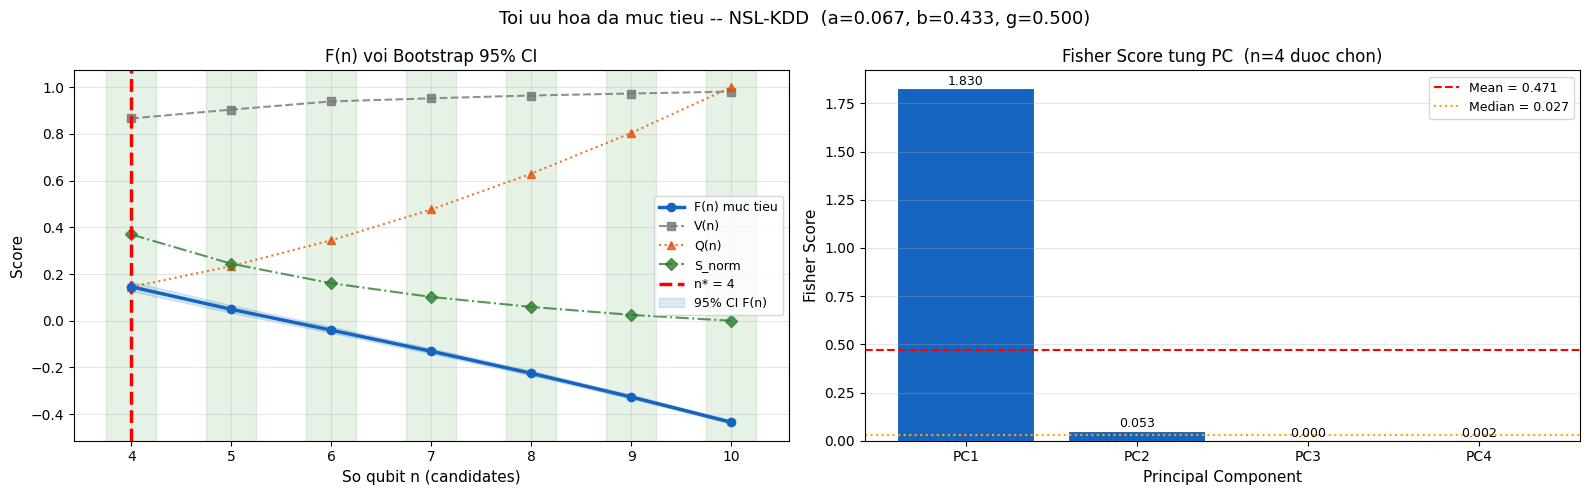

In [ ]:
n_c = [r['n'] for r in results_candidates]
f_c = [r['F_n'] for r in results_candidates]
v_c = [r['V_n'] for r in results_candidates]
q_c = [r['Q_n'] for r in results_candidates]
s_c = [r['S_norm'] for r in results_candidates]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Toi uu hoa da muc tieu -- {DATA_TYPE}  (a={alpha:.3f}, b={beta:.3f}, g={gamma:.3f})', fontsize=13)

ax = axes[0]
ax.plot(n_c, f_c, 'o-', color='#1565C0', linewidth=2.5, label='F(n) muc tieu', zorder=4)
ax.plot(n_c, v_c, 's--', color='#757575', linewidth=1.5, label='V(n)', alpha=0.8)
ax.plot(n_c, q_c, '^:', color='#E65100', linewidth=1.5, label='Q(n)', alpha=0.8)
ax.plot(n_c, s_c, 'D-.', color='#2E7D32', linewidth=1.5, label='S_norm', alpha=0.8)
ax.axvline(x=n_chosen, color='red', linestyle='--', linewidth=2.5, label=f'n* = {n_chosen}')
for r in pareto_points:
    ax.axvspan(r['n']-0.25, r['n']+0.25, alpha=0.1, color='green')
f_lo_arr = np.array([ci[n]['F_ci'][0] for n in n_c])
f_hi_arr = np.array([ci[n]['F_ci'][1] for n in n_c])
ax.fill_between(n_c, f_lo_arr, f_hi_arr, alpha=0.15, color='#1565C0', label='95% CI F(n)')
ax.set_xlabel('So qubit n (candidates)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('F(n) voi Bootstrap 95% CI')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(n_c)

ax2 = axes[1]
r_chosen  = next(r for r in results_candidates if r['n'] == n_chosen)
pc_scores = r_chosen['per_pc_scores']
pc_labels = [f'PC{i+1}' for i in range(n_chosen)]
med       = np.median(pc_scores)
colors_pc = ['#1565C0' if s >= med else '#90CAF9' for s in pc_scores]
bars = ax2.bar(pc_labels, pc_scores, color=colors_pc, edgecolor='white', linewidth=0.8)
ax2.axhline(np.mean(pc_scores), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {np.mean(pc_scores):.3f}')
ax2.axhline(med, color='orange', linestyle=':', linewidth=1.5, label=f'Median = {med:.3f}')
for bar, val in zip(bars, pc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel('Fisher Score', fontsize=11)
ax2.set_title(f'Fisher Score tung PC  (n={n_chosen} duoc chon)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_objective_fn.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. PCA cuối cùng + MinMaxScaler([0, π]) — zero-leakage

**Bước quan trọng nhất theo data_preprocessing.py:**
```
pca.fit_transform(X_train)        ← eigenvectors từ train ONLY
pca.transform(X_test)             ← NEVER fit on test
scaler.fit_transform(X_train_pca) ← min/max từ train ONLY
np.clip(scaler.transform(X_test_pca), 0, π)  ← clip test OOD values
```

Lý do scale `[0, π]` thay vì `[0, 1]`:
- RY gate: `|ψ⟩ = RY(x_i)|0⟩ = cos(x_i/2)|0⟩ + sin(x_i/2)|1⟩`
- `x_i ∈ [0, π]` khai thác toàn bộ Bloch hemisphere phía trên
- Không bị wrap-around (x > 2π sẽ alias), đảm bảo tính injectivity của embedding

In [ ]:
print(f'Applying PCA(n_components={n_chosen}) ...')
print(f'  fit_transform(X_train)  <- eigenvectors tu train ONLY')
print(f'  transform(X_test)       <- NEVER fit on test')

# -- PCA: fit on train ONLY --
pca_final   = PCA(n_components=n_chosen, random_state=GLOBAL_SEED)
X_train_pca = pca_final.fit_transform(X_train_raw)  # fit on train ONLY
X_test_pca  = pca_final.transform(X_test_raw)        # NEVER fit on test

# -- Explained variance report (theo data_preprocessing.py) --
evr   = pca_final.explained_variance_ratio_
cumev = evr.cumsum() * 100
print(f'\n  PCA Explained Variance Ratios:')
for i, (ratio, cum) in enumerate(zip(evr, cumev)):
    print(f'    PC{i+1}: {ratio:.6f}  ({ratio*100:.3f}%)  | cumulative: {cum:.4f}%')
print(f'  EXACT cumulative variance: {evr.sum()*100:.6f}%')
print(f'  Post-PCA -- train: {X_train_pca.shape} | test: {X_test_pca.shape}')

# -- MinMaxScaler([0, pi]): fit on train ONLY --
print(f'\nApplying MinMaxScaler(feature_range=(0, pi={ANGLE_MAX:.6f})) ...')
print(f'  fit_transform(X_train_pca)  <- min/max tu train ONLY')
print(f'  transform(X_test_pca)       <- NEVER fit on test')

scaler_q      = MinMaxScaler(feature_range=(0.0, ANGLE_MAX))
X_train_final = scaler_q.fit_transform(X_train_pca)           # fit on train ONLY
X_test_scaled = scaler_q.transform(X_test_pca)                # NEVER fit on test
X_test_final  = np.clip(X_test_scaled, 0, ANGLE_MAX)          # clip OOD values

print(f'  Train angle range: [{X_train_final.min():.6f}, {X_train_final.max():.6f}] rad')
print(f'  Test  angle range: [{X_test_final.min():.6f}, {X_test_final.max():.6f}] rad')
if X_test_final.min() < -1e-9 or X_test_final.max() > ANGLE_MAX + 1e-9:
    print('  WARNING: Test values outside [0, pi] -- OOD samples, clip applied')
else:
    print('  Test angles trong [0, pi]')

Applying PCA(n_components=4) ...
  fit_transform(X_train)  <- eigenvectors tu train ONLY
  transform(X_test)       <- NEVER fit on test

  PCA Explained Variance Ratios:
    PC1: 0.550645  (55.065%)  | cumulative: 55.0645%
    PC2: 0.191143  (19.114%)  | cumulative: 74.1788%
    PC3: 0.079168  (7.917%)  | cumulative: 82.0957%
    PC4: 0.045230  (4.523%)  | cumulative: 86.6187%
  EXACT cumulative variance: 86.618698%
  Post-PCA -- train: (125973, 4) | test: (22544, 4)

Applying MinMaxScaler(feature_range=(0, pi=3.141593)) ...
  fit_transform(X_train_pca)  <- min/max tu train ONLY
  transform(X_test_pca)       <- NEVER fit on test
  Train angle range: [0.000000, 3.141593] rad
  Test  angle range: [0.004428, 3.141593] rad
  Test angles trong [0, pi]


## 13. Sanity checks — zero-leakage verification

In [ ]:
print('=== SANITY CHECKS ===')
checks = []

# Check 1: So features = N_QUBITS
checks.append(('X_train_final shape = (N, N_QUBITS)',
               X_train_final.shape[1] == n_chosen,
               f'{X_train_final.shape}'))
checks.append(('X_test_final shape = (N, N_QUBITS)',
               X_test_final.shape[1] == n_chosen,
               f'{X_test_final.shape}'))

# Check 2: Train angles chinh xac trong [0, pi]
train_min = X_train_final.min()
train_max = X_train_final.max()
checks.append(('Train angles trong [0, pi] (MinMaxScaler guarantee)',
               train_min >= -1e-6 and train_max <= ANGLE_MAX + 1e-6,
               f'min={train_min:.6f}, max={train_max:.6f}'))

# Check 3: Test angles sau clip
test_min = X_test_final.min()
test_max = X_test_final.max()
checks.append(('Test angles sau clip trong [0, pi]',
               test_min >= -1e-9 and test_max <= ANGLE_MAX + 1e-9,
               f'min={test_min:.6f}, max={test_max:.6f}'))

# Check 4: Khong co NaN
checks.append(('Khong NaN trong X_train_final', np.isnan(X_train_final).sum() == 0,
               f'{np.isnan(X_train_final).sum()} NaN'))
checks.append(('Khong NaN trong X_test_final', np.isnan(X_test_final).sum() == 0,
               f'{np.isnan(X_test_final).sum()} NaN'))

# Check 5: So cot train = test
checks.append(('So cot train = test',
               X_train_final.shape[1] == X_test_final.shape[1],
               f'train={X_train_final.shape[1]}, test={X_test_final.shape[1]}'))

all_ok = True
for name, ok, detail in checks:
    status = 'OK' if ok else 'FAIL'
    print(f'  [{status}] {name:<55} {detail}')
    if not ok:
        all_ok = False

print()
if all_ok:
    print('  Tat ca checks PASSED -- san sang luu va chuyen sang QSVM')
else:
    print('  Co check FAILED -- kiem tra lai truoc khi tiep tuc')

=== SANITY CHECKS ===
  [OK] X_train_final shape = (N, N_QUBITS)                     (125973, 4)
  [OK] X_test_final shape = (N, N_QUBITS)                      (22544, 4)
  [OK] Train angles trong [0, pi] (MinMaxScaler guarantee)     min=0.000000, max=3.141593
  [OK] Test angles sau clip trong [0, pi]                      min=0.004428, max=3.141593
  [OK] Khong NaN trong X_train_final                           0 NaN
  [OK] Khong NaN trong X_test_final                            0 NaN
  [OK] So cot train = test                                     train=4, test=4

  Tat ca checks PASSED -- san sang luu va chuyen sang QSVM


## 14. Trực quan hoá PCA cuối cùng

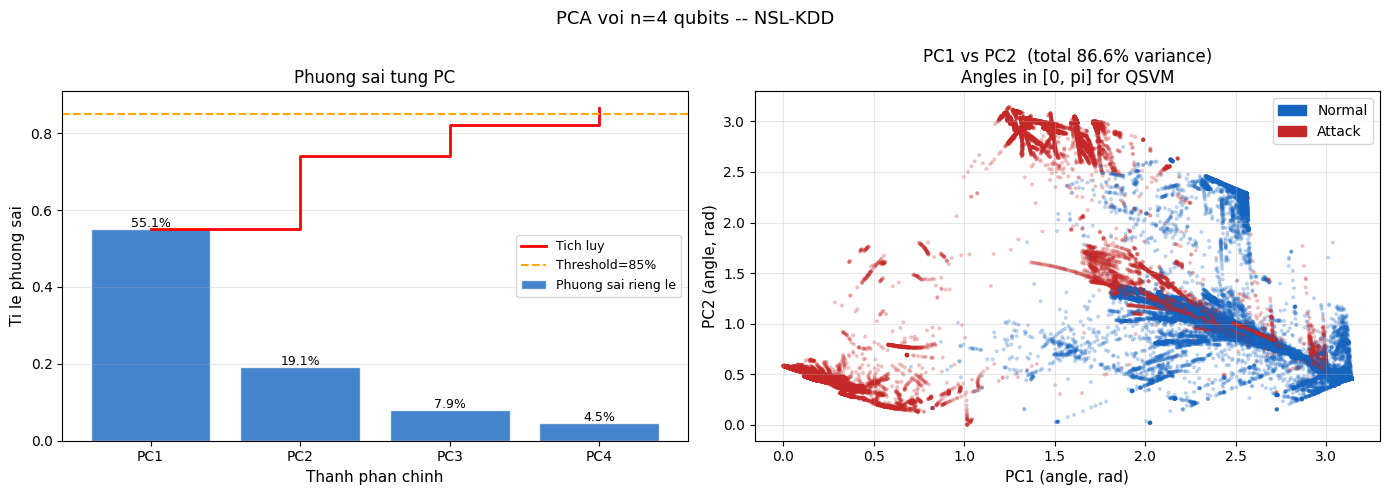

Variance giu lai: 86.62%
  PC1: 55.06%
  PC2: 19.11%
  PC3: 7.92%
  PC4: 4.52%


In [ ]:
pc_cols = [f'PC{i+1}' for i in range(n_chosen)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PCA voi n={n_chosen} qubits -- {DATA_TYPE}', fontsize=13)

ax1.bar(pc_cols, pca_final.explained_variance_ratio_,
        color='#1565C0', alpha=0.8, edgecolor='white', label='Phuong sai rieng le')
ax1.step(range(n_chosen), np.cumsum(pca_final.explained_variance_ratio_),
         where='post', color='red', linewidth=2, label='Tich luy')
ax1.axhline(VARIANCE_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
            label=f'Threshold={VARIANCE_THRESHOLD:.0%}')
for i, v in enumerate(pca_final.explained_variance_ratio_):
    ax1.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontsize=9)
ax1.set_xlabel('Thanh phan chinh', fontsize=11)
ax1.set_ylabel('Ti le phuong sai', fontsize=11)
ax1.set_title('Phuong sai tung PC')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y')

cs = ['#1565C0' if yi == 0 else '#C62828' for yi in y]
ax2.scatter(X_train_final[:, 0], X_train_final[:, 1], c=cs, alpha=0.2, s=4)
ax2.set_xlabel('PC1 (angle, rad)', fontsize=11)
ax2.set_ylabel('PC2 (angle, rad)', fontsize=11)
total_var = np.sum(pca_final.explained_variance_ratio_) * 100
ax2.set_title(f'PC1 vs PC2  (total {total_var:.1f}% variance)\nAngles in [0, pi] for QSVM')
ax2.legend(handles=[mpatches.Patch(color='#1565C0', label='Normal'),
                    mpatches.Patch(color='#C62828', label='Attack')], fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_final_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance giu lai: {total_var:.2f}%')
for i, r in enumerate(pca_final.explained_variance_ratio_):
    print(f'  PC{i+1}: {r*100:.2f}%')

## 15. Pairplot

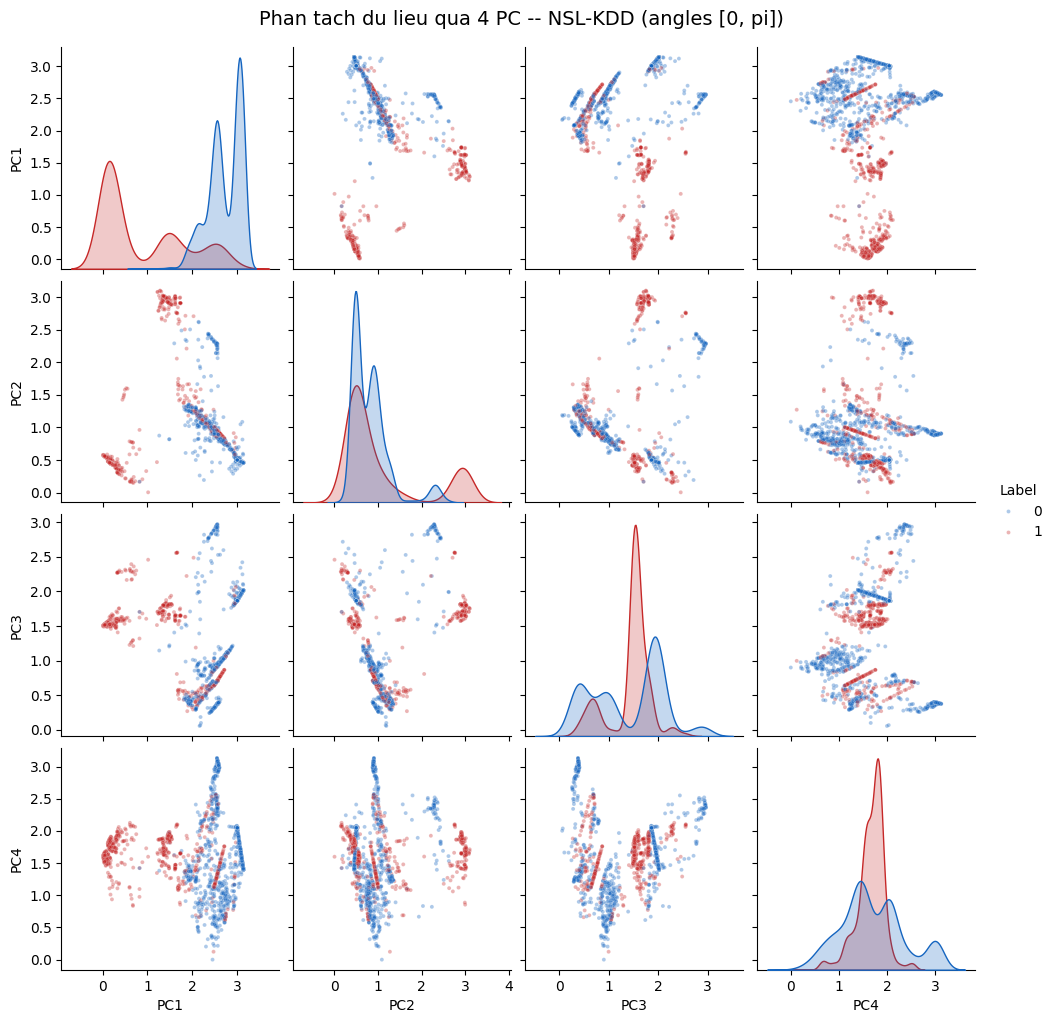

In [ ]:
pca_df          = pd.DataFrame(X_train_final, columns=pc_cols)
pca_df['Label'] = y

grid = sns.pairplot(
    pca_df.sample(min(2000, len(pca_df)), random_state=GLOBAL_SEED),
    hue='Label',
    palette={0: '#1565C0', 1: '#C62828'},
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 8}
)
grid.fig.suptitle(f'Phan tach du lieu qua {n_chosen} PC -- {DATA_TYPE} (angles [0, pi])',
                  y=1.02, fontsize=14)
plt.show()

## 16. Phân tích tương quan — Tiền đề cho ZZFeatureMap

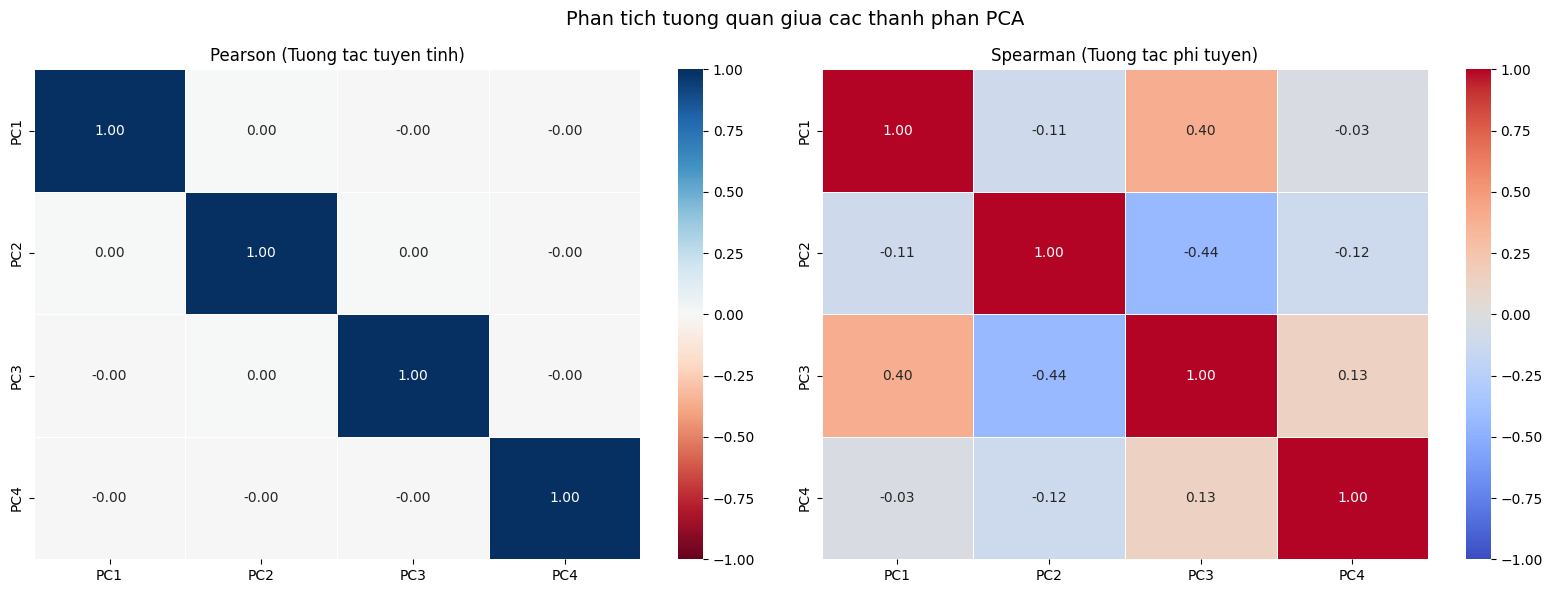

Tuong quan Spearman |r| > 0.2 -- Tien de cho ZZFeatureMap:
   PC2 <-> PC3 : r = -0.437
   PC1 <-> PC3 : r = +0.397

ZZFeatureMap ma hoa tuong tac cap (xi, xj) vao pha luong tu
  -> khai thac cau truc phi tuyen ma Linear SVM bo sot.


In [ ]:
corr_pearson  = pca_df.drop('Label', axis=1).corr(method='pearson')
corr_spearman = pca_df.drop('Label', axis=1).corr(method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phan tich tuong quan giua cac thanh phan PCA', fontsize=14)
sns.heatmap(corr_pearson,  annot=True, cmap='RdBu',    fmt='.2f',
            ax=ax1, linewidths=0.5, vmin=-1, vmax=1)
ax1.set_title('Pearson (Tuong tac tuyen tinh)')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f',
            ax=ax2, linewidths=0.5, vmin=-1, vmax=1)
ax2.set_title('Spearman (Tuong tac phi tuyen)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

sig_pairs = []
for i in range(len(pc_cols)):
    for j in range(i+1, len(pc_cols)):
        val = corr_spearman.loc[pc_cols[i], pc_cols[j]]
        if abs(val) > 0.2:
            sig_pairs.append((pc_cols[i], pc_cols[j], val))

print('Tuong quan Spearman |r| > 0.2 -- Tien de cho ZZFeatureMap:')
if sig_pairs:
    for p1, p2, val in sorted(sig_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'   {p1} <-> {p2} : r = {val:+.3f}')
    print()
    print('ZZFeatureMap ma hoa tuong tac cap (xi, xj) vao pha luong tu')
    print('  -> khai thac cau truc phi tuyen ma Linear SVM bo sot.')
else:
    print('  Khong co cap dang ke -- cau truc phi tuyen yeu o n nay.')

## 17. Lưu tất cả output + artifacts

In [ ]:
# -- 2. Transformers: .joblib (sklearn-recommended) --
joblib.dump(pca_final, f'{MODELS_DIR}/pca_{n_chosen}components.joblib')
joblib.dump(scaler_q,  f'{MODELS_DIR}/scaler_minmax_pi.joblib')

# -- 3. Metadata --
pd.DataFrame({
    'pc'                    : pc_cols,
    'explained_variance'    : pca_final.explained_variance_ratio_,
    'cumulative_variance'   : np.cumsum(pca_final.explained_variance_ratio_),
}).to_csv(f'{OUTPUT_DIR}/pca_variance_report.csv', index=False)

print('=== DA LUU ===')
for fname, info in [
    (f'models/pca_{n_chosen}components.joblib', 'PCA object'),
    ('models/scaler_minmax_pi.joblib',      f'MinMaxScaler([0, {ANGLE_MAX:.4f}])'),
    ('pca_variance_report.csv',             f'{n_chosen} PCs'),
]:
    print(f'  {fname:<50} {str(info)}')

print(f'\n-> Buoc tiep theo: QSVM training')
print(f'   Input X_train : {X_train_final.shape}  (dtype={X_train_final.dtype})')
print(f'   Input X_test  : {X_test_final.shape}')
print(f'   Angle range   : [0, {ANGLE_MAX:.6f}] rad  (= [0, pi])')
print(f'   Circuit       : {n_chosen}-qubit ZZFeatureMap')

=== DA LUU ===
  X_train_pca.npy                                    (125973, 4)
  X_test_pca.npy                                     (22544, 4)
  y_train.npy                                        (125973,)
  y_test.npy                                         (22544,)
  models/pca_4components.joblib                      PCA object
  models/scaler_minmax_pi.joblib                     MinMaxScaler([0, 3.1416])
  pca_variance_report.csv                            4 PCs

-> Buoc tiep theo: QSVM training
   Input X_train : (125973, 4)  (dtype=float32)
   Input X_test  : (22544, 4)
   Angle range   : [0, 3.141593] rad  (= [0, pi])
   Circuit       : 4-qubit ZZFeatureMap


## 18. Paper-ready summary

In [ ]:
ci_chosen    = ci[n_chosen]
eliminated_n = [r['n'] for r in results_all if not r['passes_hard']]

print('=' * 65)
print('  CONTRIBUTION 1 -- HARDWARE-AWARE QUANTUM EMBEDDING  (v4)')
print(f'  Dataset: {DATA_TYPE}')
print('=' * 65)
print(f'  [Input]')
print(f'    SelectKBest output     : {X_train_raw.shape[1]} features (sau f_classif K={X_train_raw.shape[1]})')
print()
print(f'  [Hard Constraint]')
print(f'    Variance threshold     : >= {VARIANCE_THRESHOLD:.0%}')
print(f'    Bi loai                : n in {eliminated_n}')
print(f'    Candidates hop le      : n in {n_candidates}')
print()
print(f'  [Toi uu hoa trong so -- Simplex Grid Search + DBI]')
print(f'    Grid resolution        : {GRID_RESOLUTION} -> {len(simplex_grid(GRID_RESOLUTION))} diem')
print(f'    Metric                 : Davies-Bouldin Index (O(k*n))')
print(f'    a (variance)           = {alpha:.4f}')
print(f'    b (fisher)             = {beta:.4f}')
print(f'    g (hardware)           = {gamma:.4f}')
print(f'    Best DBI               = {best_dbi:.4f}')
print()
print(f'  [Ket qua]')
print(f'    n toi uu               : {n_chosen} qubits')
print(f'    Variance giu lai       : {best_candidate["V_n"]:.2%}')
print(f'    Fisher Score S(n)      : {best_candidate["S_n"]:.4f}')
print(f'    Davies-Bouldin Index   : {best_candidate["DBI"]:.4f}')
print(f'    Silhouette Score       : {best_candidate.get("silhouette", float("nan")):.4f}')
print(f'    Hardware cost Q(n)     : {best_candidate["Q_n"]:.4f}')
print(f'    Objective F(n)         : {best_candidate["F_n"]:.4f}')
print()
print(f'  [Quantum Angle Encoding]')
print(f'    Scale                  : MinMaxScaler([0, {ANGLE_MAX:.6f}]) = [0, pi]')
print(f'    Train angle range      : [{X_train_final.min():.6f}, {X_train_final.max():.6f}] rad')
print(f'    Test  angle range      : [{X_test_final.min():.6f}, {X_test_final.max():.6f}] rad')
print(f'    Zero-leakage           : fit_transform(train) / clip(transform(test), 0, pi)')
print()
print(f'  [Bootstrap 95% CI -- n={N_BOOTSTRAP} iters]')
print(f'    F(n) CI                : [{ci_chosen["F_ci"][0]:.4f}, {ci_chosen["F_ci"][1]:.4f}]')
print(f'    Silhouette CI          : [{ci_chosen["sil_ci"][0]:.4f}, {ci_chosen["sil_ci"][1]:.4f}]')
print()
print(f'  [Artifacts]')
print(f'    models/pca_{n_chosen}components.joblib')
print(f'    models/scaler_minmax_pi.joblib')
print(f'    X_train_pca.npy  {X_train_final.shape}  dtype={X_train_final.dtype}')
print(f'    X_test_pca.npy   {X_test_final.shape}')
print('=' * 65)

  CONTRIBUTION 1 -- HARDWARE-AWARE QUANTUM EMBEDDING  (v4)
  Dataset: NSL-KDD
  [Input]
    SelectKBest output     : 20 features (sau f_classif K=20)

  [Hard Constraint]
    Variance threshold     : >= 85%
    Bi loai                : n in [2, 3]
    Candidates hop le      : n in [4, 5, 6, 7, 8, 9, 10]

  [Toi uu hoa trong so -- Simplex Grid Search + DBI]
    Grid resolution        : 30 -> 496 diem
    Metric                 : Davies-Bouldin Index (O(k*n))
    a (variance)           = 0.0667
    b (fisher)             = 0.4333
    g (hardware)           = 0.5000
    Best DBI               = 1.0846

  [Ket qua]
    n toi uu               : 4 qubits
    Variance giu lai       : 86.62%
    Fisher Score S(n)      : 0.4711
    Davies-Bouldin Index   : 1.0846
    Silhouette Score       : 0.4262
    Hardware cost Q(n)     : 0.1447
    Objective F(n)         : 0.1455

  [Quantum Angle Encoding]
    Scale                  : MinMaxScaler([0, 3.141593]) = [0, pi]
    Train angle range      : [0.